<a href="https://colab.research.google.com/github/weee-is-nerd/Bristol_population_prediction/blob/main/Bristol_population.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bristol Population Prediction Project (2011-2026)

This notebook presents a simple workflow for predicting Bristol's population using annual demographic indicators from 2011 to 2024.
The workflow includes


*   loading and reshaping the Bristol dataset
*   cleaning and preparing the yearly records


*   exploratory data analysis (EDA)
*   training multiple prediction models


*   comparing model performance
*   selecting the best model


*   forecasting Bristol's population for 2025 and 2026









# Imports and data setup

This section imports the main Python libraries used in the project.

*   `pandas` is used to handle and organise the dataset,
*   `numpy` supports numerical calculations,


*   `matplotlib` is used to create visualisations, and
*   `scikit-learn` provides the machine learning models for prediction.










In [2]:
# Import the libraries needed for the analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load the Excel file and keep Bristol only

The uploaded Excel file contains data for multiple local authorities. Since this project focuses only on Bristol, the first task is to load the file and filter the dataset so that only B**ristol, City** of remains.


In [22]:
# Load the dataset
file = "bristolpopulation20112024.xlsx"

city = pd.read_excel(file, header=1)

# Keep only Bristol, City of
bristol = city[city["laname23"] == "Bristol, City of"].copy()

bristol = bristol.iloc[0]

print("Excel file loaded successfully.")
print("Bristol row selected successfully.")

Excel file loaded successfully.
Bristol row selected successfully.


# Reshape the dataset into yearly rows

The raw Excel file stores data in a wide format, where each year is written inside the column name, for example, `population_2011`, `population_2012`, and so on.

For analysis and modelling, the dataset needs to be converted into a long format, where each row represents one year. This is easier to read, easier to plot, and much more suitable for machine-learning models.

In [23]:
# Convert the wide Excel format into a tidy yearly table
df_rows = []

for year in range(2011, 2025):
    row = {
        "year": year,
        "population": bristol.get(f"population_{year}", np.nan),
        "births": bristol.get(f"births_{year}", np.nan),
        "deaths": bristol.get(f"deaths_{year}", np.nan),
        "natchange": bristol.get(f"natchange_{year}", np.nan),
        "internal_net": bristol.get(f"internal_net_{year}", np.nan),
        "international_net": bristol.get(f"international_net_{year}", np.nan),
        "other_change": bristol.get(f"other_change_{year}", np.nan),
    }
    df_rows.append(row)

df = pd.DataFrame(df_rows)

print("Tidy Bristol population table created.")
df

Tidy Bristol population table created.


,year,population,births,deaths,natchange,internal_net,international_net,other_change
0,2011,428074,NaN,NaN,NaN,NaN,NaN,NaN
1,2012,433264,6867.0,3328.0,3539.0,424.0,1768.0,-541.0
2,2013,438984,6632.0,3403.0,3229.0,544.0,2751.0,-804.0
3,2014,443834,6421.0,3307.0,3114.0,-105.0,2787.0,-946.0
4,2015,451790,6376.0,3361.0,3015.0,2377.0,3771.0,-1207.0
5,2016,459588,6388.0,3327.0,3061.0,1874.0,4267.0,-1404.0
6,2017,463113,6205.0,3401.0,2804.0,777.0,1812.0,-1868.0
7,2018,467026,5850.0,3489.0,2361.0,1027.0,2525.0,-2000.0
8,2019,469920,5669.0,3366.0,2303.0,661.0,2325.0,-2395.0
9,2020,471851,5428.0,3554.0,1874.0,291.0,1926.0,-2160.0


# Handle missing values

Some early-year variables may be missing, especially where change variables are not available for the base year. To keep the workflow simple and transparent, missing values in the demographic change columns are replaced with zero.

In [24]:
# Handle missing values with zero
for col in ["births", "deaths", "natchange", "internal_net", "international_net", "other_change"]:
    df[col] = df[col].fillna(0)

print("Missing values handled.")
df

Missing values handled.


,year,population,births,deaths,natchange,internal_net,international_net,other_change
0,2011,428074,0.0,0.0,0.0,0.0,0.0,0.0
1,2012,433264,6867.0,3328.0,3539.0,424.0,1768.0,-541.0
2,2013,438984,6632.0,3403.0,3229.0,544.0,2751.0,-804.0
3,2014,443834,6421.0,3307.0,3114.0,-105.0,2787.0,-946.0
4,2015,451790,6376.0,3361.0,3015.0,2377.0,3771.0,-1207.0
5,2016,459588,6388.0,3327.0,3061.0,1874.0,4267.0,-1404.0
6,2017,463113,6205.0,3401.0,2804.0,777.0,1812.0,-1868.0
7,2018,467026,5850.0,3489.0,2361.0,1027.0,2525.0,-2000.0
8,2019,469920,5669.0,3366.0,2303.0,661.0,2325.0,-2395.0
9,2020,471851,5428.0,3554.0,1874.0,291.0,1926.0,-2160.0


# Create additional features for prediciton

Feature engineering is used to improve the model by creating variables based on previous population values.

Tow lag variables are created,


*   `lag_population_1`: previous year's population
*   `lag_population_2`: population from two years earlier

A yearly difference variable is also created,


*   `population_change`: the difference in population from one year to the next

These variables help the model learn time-based patterns more effectively.





In [25]:
# Create lag features and annual change
df["lag_population_1"] = df["population"].shift(1)
df["lag_population_2"] = df["population"].shift(2)

df["population_change"] = df["population"].diff()

df_model = df.dropna().copy()

print("Feature engineering completed.")
df_model

Feature engineering completed.


,year,population,births,deaths,natchange,internal_net,international_net,other_change,lag_population_1,lag_population_2,population_change
2,2013,438984,6632.0,3403.0,3229.0,544.0,2751.0,-804.0,433264.0,428074.0,5720.0
3,2014,443834,6421.0,3307.0,3114.0,-105.0,2787.0,-946.0,438984.0,433264.0,4850.0
4,2015,451790,6376.0,3361.0,3015.0,2377.0,3771.0,-1207.0,443834.0,438984.0,7956.0
5,2016,459588,6388.0,3327.0,3061.0,1874.0,4267.0,-1404.0,451790.0,443834.0,7798.0
6,2017,463113,6205.0,3401.0,2804.0,777.0,1812.0,-1868.0,459588.0,451790.0,3525.0
7,2018,467026,5850.0,3489.0,2361.0,1027.0,2525.0,-2000.0,463113.0,459588.0,3913.0
8,2019,469920,5669.0,3366.0,2303.0,661.0,2325.0,-2395.0,467026.0,463113.0,2894.0
9,2020,471851,5428.0,3554.0,1874.0,291.0,1926.0,-2160.0,469920.0,467026.0,1931.0
10,2021,471285,5315.0,3421.0,1894.0,-3403.0,2929.0,-1986.0,471851.0,469920.0,-566.0
11,2022,479639,5181.0,3646.0,1535.0,-769.0,7623.0,-35.0,471285.0,471851.0,8354.0


# Exploratory Data Analysis (EDA)

Before building prediction models, it is important to understand the dataset visually. In EDA session, figures such as
- the overall population trend
- yearly change in population
- births and deaths over time
- internal and international migration patterns

will be shown.

These figures are useful both for interpretation and for writing the results chapter.

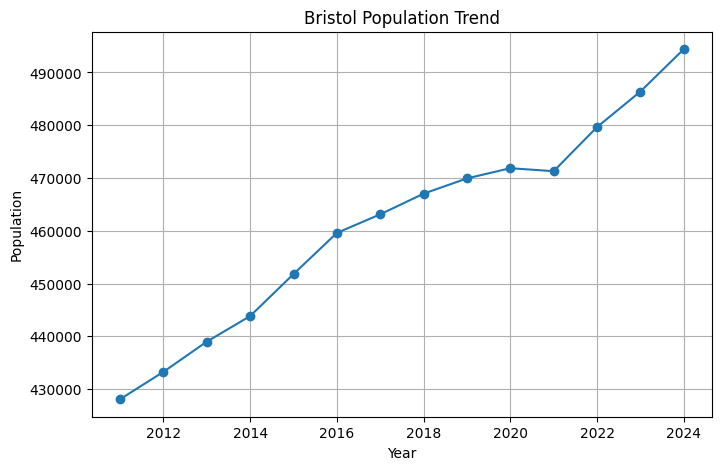

In [26]:
# Figure 1 - Bristol population trend over time
plt.figure(figsize=(8, 5))
plt.plot(df["year"], df["population"], marker="o")
plt.title("Bristol Population Trend")
plt.xlabel("Year")
plt.ylabel("Population")
plt.grid(True)
plt.show()

## Figure 1 note

This figure shows the overall direction of Bristol's population across time. A steady upward line would suggest that the city has experienced long-term growth, while flatter or declining sections would suggest slower growth or temporary population change.

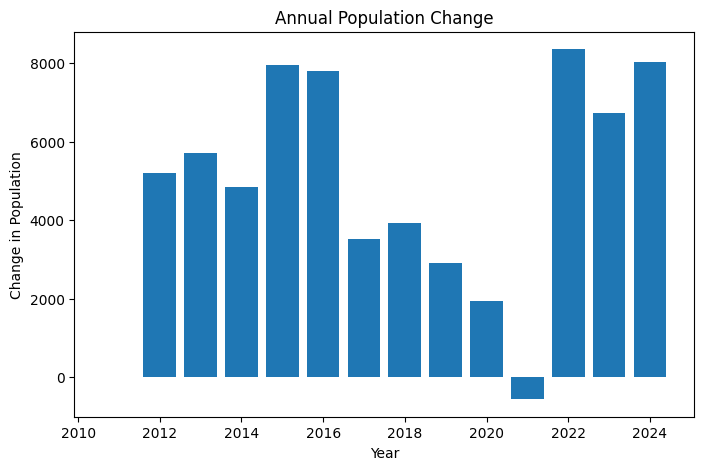

In [27]:
# Figure 2 - Annual population change
plt.figure(figsize=(8, 5))
plt.bar(df["year"], df["population_change"].fillna(0))
plt.title("Annual Population Change")
plt.xlabel("Year")
plt.ylabel("Change in Population")
plt.show()

## Figure 2 note

This bar chart shows how much the population increased or decreased each year. Positive bars represent growth, while negative bars would represent decline. This makes it easier to identify years with stronger or weaker change.

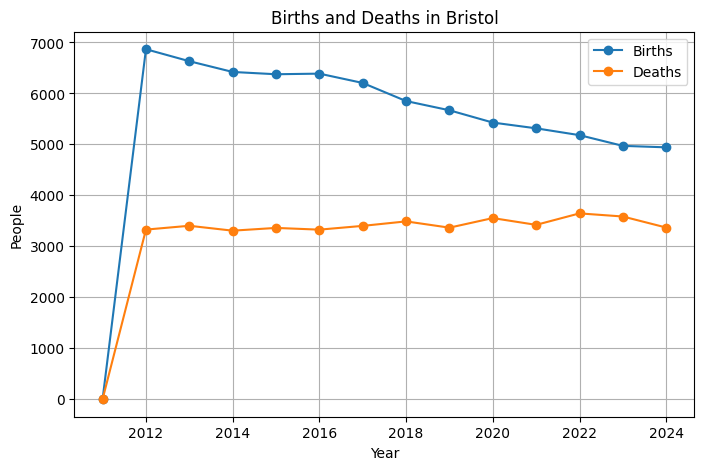

In [28]:
# Figure 3 - Births and deaths over time
plt.figure(figsize=(8, 5))
plt.plot(df["year"], df["births"], marker="o", label="Births")
plt.plot(df["year"], df["deaths"], marker="o", label="Deaths")
plt.title("Births and Deaths in Bristol")
plt.xlabel("Year")
plt.ylabel("People")
plt.legend()
plt.grid(True)
plt.show()

## Figure 3 note

This figure compares annual births and deaths. It helps show whether natural population change contributes positively to Bristol's growth. If births remain above deaths in most years, natural change is likely supporting the increase in population.

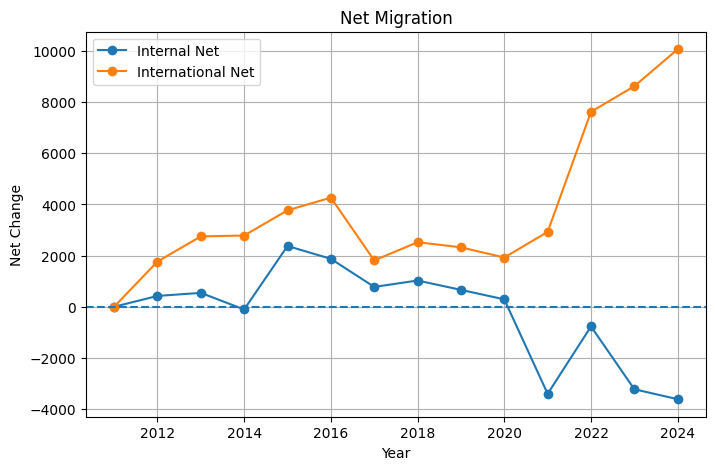

In [29]:
# Figure 4 - Internal and international net migration
plt.figure(figsize=(8, 5))
plt.plot(df["year"], df["internal_net"], marker="o", label="Internal Net")
plt.plot(df["year"], df["international_net"], marker="o", label="International Net")
plt.axhline(0, linestyle="--")
plt.title("Net Migration")
plt.xlabel("Year")
plt.ylabel("Net Change")
plt.legend()
plt.grid(True)
plt.show()

## Figure 4 note

This figure shows the contribution of migration to population change. Values above zero indicate net gains, while values below zero indicate net losses. Comparing internal and international migration can help explain whether population growth is mainly driven by movement within the UK or from abroad.

# Prepare the modelling dataset

The model needs a set of input variables (`x`) and a target variable (`y`).

The input features include time, births, deaths, migration variables, and lagged population values. These are used to predict the population level in each year.

The target variable is the annual Bristol population.



In [30]:
# Choose the model features and target
features = [
    "year",
    "births",
    "deaths",
    "natchange",
    "internal_net",
    "international_net",
    "other_change",
    "lag_population_1",
    "lag_population_2"
]

X = df_model[features]
y = df_model["population"]

print("Features and target prepared.")
print("X shape:", X.shape)
print("y shape:", y.shape)

Features and target prepared.
X shape: (12, 9)
y shape: (12,)


# Training and testing split

To make the prediction more realistic, the data is split by time,
- earlier years are used for training
- later years are used for testing

This mirrors the real forecasting situation, where past information is used to predict future values.

In [31]:
# Split the data into training and testing periods
train = df_model[df_model["year"] <= 2021]
test = df_model[df_model["year"] > 2021]

X_train = train[features]
y_train = train["population"]

X_test = test[features]
y_test = test["population"]

print("Training years:")
print(train["year"].tolist())
print("Testing years:")
print(test["year"].tolist())

Training years:
[2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]
Testing years:
[2022, 2023, 2024]


# Build several prediciton models

To compare different approaches, five models are tested,
- Linear Regression
- Ridge Regression
- Lasso Regression
- Random Forest
- Histogram-Based Gradient Boosting

The simpler linear models provide a baseline, while the tree-based models are included because they can capture more complex non-linear relationships.

In [32]:
# Define the models used in the comparison
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "HistGradientBoosting": HistGradientBoostingRegressor(random_state=42)
}

print("Models ready for training.")

Models ready for training.


# Train the models and compare performance

Each model is trained using the training dataset and then evaluated on the testing dataset using
- **MAE**: average error
- **RMSE**: larger errors are penalised more heavily
- **R²**: how well the model explains the observed variation

The model with the lowest RMSE is selected as the best-performing model.

In [33]:
# Train each model and store the evaluation results
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    results.append([name, mae, rmse, r2])

results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2"])
results_df = results_df.sort_values("RMSE").reset_index(drop=True)

results_df

,Model,MAE,RMSE,R2
0,Linear Regression,1.164153e-10,1.164153e-10,1.000000
1,Ridge,6.162779e-02,6.917373e-02,1.000000
2,Lasso,1.316540e+03,1.456276e+03,0.941740
3,Random Forest,1.908856e+04,2.009021e+04,-10.087918
4,HistGradientBoosting,2.709456e+04,2.775818e+04,-20.167174


## Model results note

This table compares the predictive performance of all models. Lower MAE and RMSE values indicate better prediction accuracy, while a higher R² value indicates stronger explanatory performance. In this notebook, RMSE is used to select the final model because it gives more weight to larger prediction errors.

In [34]:
# Select and refit the best-performing model
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

best_model.fit(X_train, y_train)

test_pred = best_model.predict(X_test)

print("Best model selected:", best_model_name)

Best model selected: Linear Regression


# Diagnostic figures for the best model

After selecting the strongest model, two diagnostic figures are created,
- **Actual vs Predicted**: shows how close the predictions are to the real values
- **Residual Plot**: shows the size and direction of the prediction errors

These charts help explain model performance more clearly than a table alone.

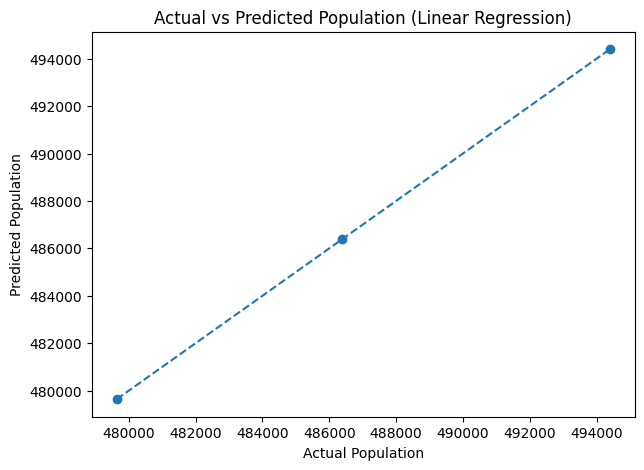

In [35]:
# Figure 5 - Actual vs predicted values
plt.figure(figsize=(7, 5))
plt.scatter(y_test, test_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle="--")
plt.title(f"Actual vs Predicted Population ({best_model_name})")
plt.xlabel("Actual Population")
plt.ylabel("Predicted Population")
plt.show()

## Figure 5 note

This scatter plot compares the real population values with the predicted values produced by the best model. Points closer to the dashed diagnoal line indicate stronger predictive accuracy. If many points fall far from the line, the model is making larger errors.

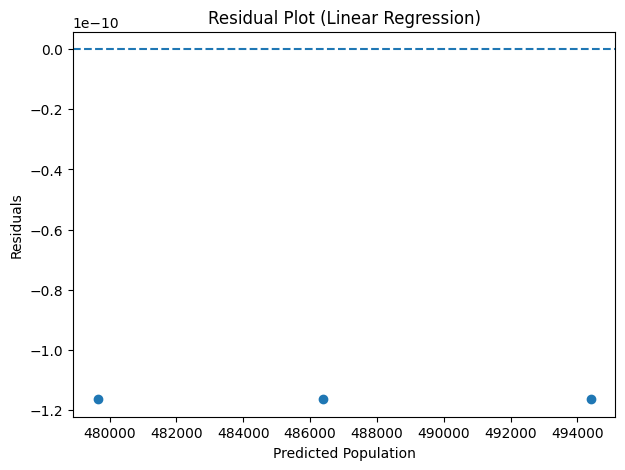

In [36]:
# Figure 6 - Residual plot

# Residual = actual value - predicted value
residuals = y_test - test_pred

plt.figure(figsize=(7, 5))
plt.scatter(test_pred, residuals)
plt.axhline(0, linestyle="--")
plt.title(f"Residual Plot ({best_model_name})")
plt.xlabel("Predicted Population")
plt.ylabel("Residuals")
plt.show()

## Figure 6 note

This figure shows the model's errors. A random spread of points around the zero line usually suggests that the model is reasonably balanced. A clear pattern or a widening spread may suggest that the model struggles more for certain values.

# Forecast Bristol's population for 2025 and 2026

The final stage uses the selected model to forecast future population values.

Because future births, deaths, and migration values are not yet known, their historical averages are used as a simple approximation. The model then predicts 2025 first, followed by 2026, using the previously predicted value as part of the lag structure.

In [37]:
# Forecast population for 2025 and 2026
forecast_df = df.copy()

for future_year in [2025, 2026]:

    last_row = forecast_df.iloc[-1]
    second_last_row = forecast_df.iloc[-2]


    new_row = {
        "year": future_year,
        "births": forecast_df["births"].mean(),
        "deaths": forecast_df["deaths"].mean(),
        "natchange": forecast_df["natchange"].mean(),
        "internal_net": forecast_df["internal_net"].mean(),
        "international_net": forecast_df["international_net"].mean(),
        "other_change": forecast_df["other_change"].mean(),
        "lag_population_1": last_row["population"],
        "lag_population_2": second_last_row["population"],
    }

    # Make the future prediction
    X_future = pd.DataFrame([new_row])[features]
    predicted_population = best_model.predict(X_future)[0]


    new_row["population"] = predicted_population
    new_row["population_change"] = predicted_population - last_row["population"]


    forecast_df = pd.concat([forecast_df, pd.DataFrame([new_row])], ignore_index=True)

forecast_result = forecast_df[forecast_df["year"] >= 2024][["year", "population"]]
forecast_result

,year,population
13,2024,494399.0
14,2025,499136.5
15,2026,503874.0


### Forecast note

The forecast table shows the last observed year and the two future years predicted by the model. These values should be interpreted as exploratory projections rather than exact future counts, because future demographic drivers are approximated using historical averages.

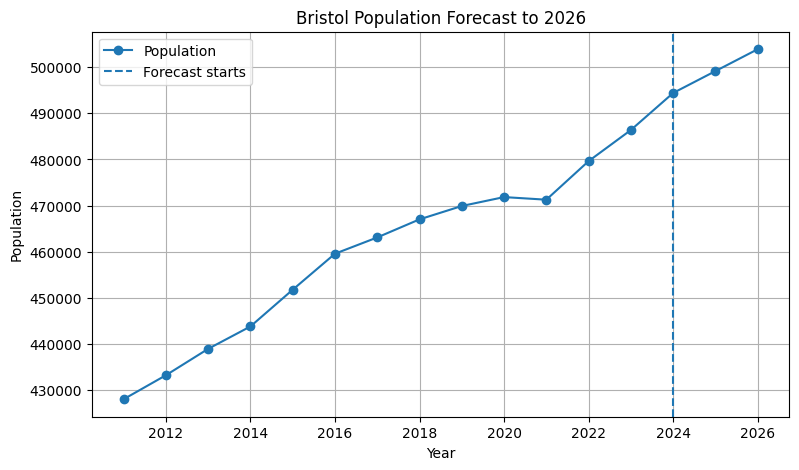

In [38]:
# Figure 8 - Final historical trend with forecast
plt.figure(figsize=(9, 5))
plt.plot(forecast_df["year"], forecast_df["population"], marker="o", label="Population")
plt.axvline(2024, linestyle="--", label="Forecast starts")
plt.title("Bristol Population Forecast to 2026")
plt.xlabel("Year")
plt.ylabel("Population")
plt.legend()
plt.grid(True)
plt.show()

## Figure 8 note

This final figure combines the historical population data with the forecast for 2025 and 2026. The dashed vertical line marks the point where the observed data ends and the forecast begins. This chart provides a simple visual summary of the full project outcome.

## Final summary

This notebook follows a simple end-to-end population prediction workflow,
1. load the Bristol dataset
2. convert it into a tidy yearly format
3. clean the data and create lag features
4. explore patterns using charts
5. train multiple models
6. compare performance using MAE, RMSE, and R²
7. select the best model
8. forecast Bristol's population for 2025 and 2026

The structure and commentary are written in an assignment-ready style so the notebook can support both the methodology and results sections of the report.